# Проверка трёхстанционного подтверждения

Этот notebook читает готовые 12 аудиопотоков и 48 повторов трекера из `results/robust_track_confirmation`. Алгоритм здесь не запускается и параметры не подбираются. Единица парного сравнения — целый поток/метод, а не перекрывающийся кадр. Истинные координаты применяются только для проверки ошибки.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from validation.gazebo_experiment import sha256
project = Path.cwd().resolve()
if not (project / "results").exists():
    project = project.parent
root = project / "results" / "robust_track_confirmation"
manifest = json.loads((root / "evaluation_manifest.json").read_text())
summary = json.loads((root / "evaluation_summary.json").read_text())
assert len(manifest["specs"]) == 12 and summary["tracker_replay_count"] == 48
for name, expected in summary["tables"].items():
    assert sha256(root / name) == expected
runs = pd.read_csv(root / "run_summary.csv")
method = pd.read_csv(root / "method_summary.csv")
pairs = pd.read_csv(root / "paired_summary.csv")
assert len(runs) == 48 and len(pairs) == 24
print(summary["verdict"])
method[["estimator_variant", "confirmation_variant", "confirmed_stream_count", "severe_confirmation_over_50m_count_all_12", "confirmed_availability_fraction", "median_first_confirmation_time_s"]]

improvement_confirmed_in_limited_protocol


,estimator_variant,confirmation_variant,confirmed_stream_count,severe_confirmation_over_50m_count_all_12,confirmed_availability_fraction,median_first_confirmation_time_s
0,all_6_equal_gcc_wls,baseline,9,5,0.601496,1.055312
1,all_6_equal_gcc_wls,three_station_confirmation,9,4,0.586004,1.055312
2,equal_weight_srp_phat,baseline,12,8,0.785256,2.435646
3,equal_weight_srp_phat,three_station_confirmation,12,7,0.754808,3.964146


## Состояние при первом подтверждении

Порог 50 м определён в замороженном протоколе до новых потоков. Отсутствующие подтверждения показаны отдельно; их не следует считать нулевой ошибкой.

In [2]:
# Сводка по целым потокам; условные ошибки оставлены рядом с долей доступности.
summary_by_method = runs.groupby(["estimator_variant", "confirmation_variant"], dropna=False).agg(
    streams=("run_id", "size"), confirmed=("ever_confirmed", "sum"),
    first_time_median_s=("first_confirmation_time_s_relative", "median"),
    first_position_error_median_m=("first_confirmation_position_error_m", "median"),
    first_velocity_error_median_mps=("first_confirmation_velocity_error_mps", "median"),
    first_radial_abs_median_m=("first_confirmation_radial_error_m", lambda values: values.abs().median()),
    first_transverse_median_m=("first_confirmation_transverse_error_m", "median"),
    conditional_rmse_median_m=("position_rmse_m_conditional", "median"),
    conditional_p95_median_m=("position_p95_m_conditional", "median"),
    valid_publications=("valid_publication_count", "sum"),
    all_publications=("publication_count", "sum"),
    accepted_updates=("accepted_update_count", "sum"),
    rejected_updates=("rejected_update_count", "sum"),
    batch_fits=("batch_optimization_count", "sum"),
    tracker_runtime_s=("tracker_runtime_s", "sum"),
    peak_history_memory_bytes=("maximum_history_memory_bytes", "max"),
    position_nees_run_median=("position_nees_median", "median"),
    position_coverage_run_median=("position_nominal_95_coverage", "median"),
).reset_index()
summary_by_method["valid_availability"] = summary_by_method.valid_publications / summary_by_method.all_publications
summary_by_method["failure_count"] = summary_by_method.streams - summary_by_method.confirmed
display(summary_by_method)

,estimator_variant,confirmation_variant,streams,confirmed,first_time_median_s,first_position_error_median_m,first_velocity_error_median_mps,first_radial_abs_median_m,first_transverse_median_m,conditional_rmse_median_m,...,all_publications,accepted_updates,rejected_updates,batch_fits,tracker_runtime_s,peak_history_memory_bytes,position_nees_run_median,position_coverage_run_median,valid_availability,failure_count
0,all_6_equal_gcc_wls,baseline,12,9,1.055312,62.516357,17.079756,62.085252,1.728019,46.982063,...,1872,752,366,568,1282.727606,2184744,4.694560,1.000000,0.601496,3
1,all_6_equal_gcc_wls,three_station_confirmation,12,9,1.055312,27.226996,8.861211,25.741966,1.728019,29.170932,...,1872,825,264,625,1287.932010,2184744,7.349545,0.520000,0.586004,3
2,equal_weight_srp_phat,baseline,12,12,2.435646,104.970785,21.695431,103.402723,5.338618,286.830780,...,1872,767,691,263,62.735588,2184744,5.470232,0.690763,0.785256,0
3,equal_weight_srp_phat,three_station_confirmation,12,12,3.964146,69.906394,15.874654,69.281529,4.584468,93.656775,...,1872,874,528,422,65.895832,2184744,10.406235,0.371261,0.754808,0


In [3]:
from collections import Counter
failure_rows = []
for (method_name, variant_name), group in runs.groupby(["estimator_variant", "confirmation_variant"]):
    causes = Counter()
    for encoded in group.update_rejection_reasons:
        causes.update(json.loads(encoded))
    failure_rows.append({
        "estimator_variant": method_name, "confirmation_variant": variant_name,
        "no_confirmation_count": int((~group.ever_confirmed).sum()),
        "final_unconfirmed_count": int((~group.final_confirmed).sum()),
        "budget_exhaustion_count": int(group.first_budget_exhaustion_time_s.notna().sum()),
        "rejected_update_reasons": dict(causes),
        "final_failure_reasons": group.final_failure_reason.dropna().value_counts().to_dict(),
    })
display(pd.DataFrame(failure_rows))

,estimator_variant,confirmation_variant,no_confirmation_count,final_unconfirmed_count,budget_exhaustion_count,rejected_update_reasons,final_failure_reasons
0,all_6_equal_gcc_wls,baseline,3,4,3,"{'emission_outside_history': 265, 'pre_update_...","{'computational_budget_exceeded': 3, 'tentativ..."
1,all_6_equal_gcc_wls,three_station_confirmation,3,4,3,"{'emission_outside_history': 139, 'pre_update_...","{'computational_budget_exceeded': 3, 'tentativ..."
2,equal_weight_srp_phat,baseline,0,0,0,"{'emission_outside_history': 588, 'pre_update_...",{}
3,equal_weight_srp_phat,three_station_confirmation,0,1,0,"{'emission_outside_history': 308, 'pre_update_...",{'tentative_initialization_unconfirmed': 1}


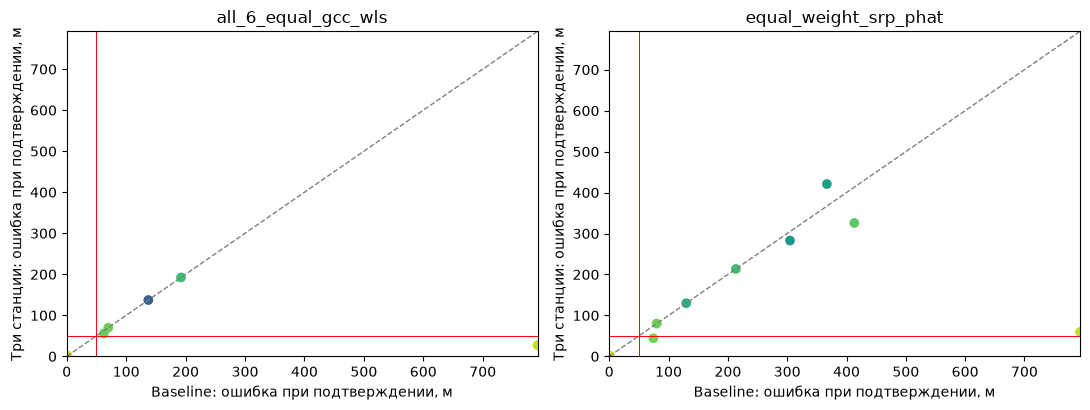

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, estimator in zip(axes, sorted(pairs.estimator_variant.unique())):
    part = pairs[pairs.estimator_variant == estimator]
    common = part.dropna(subset=["baseline_first_position_error_m", "new_first_position_error_m"])
    ax.scatter(common.baseline_first_position_error_m, common.new_first_position_error_m,
               c=common.baseline_availability, cmap="viridis", vmin=0, vmax=1)
    lim = max(50, part[["baseline_first_position_error_m", "new_first_position_error_m"]].max().max())
    ax.plot([0, lim], [0, lim], color="grey", linestyle="--", linewidth=1)
    ax.axvline(50, color="red", linewidth=0.7)
    ax.axhline(50, color="red", linewidth=0.7)
    ax.set(xlim=(0, lim), ylim=(0, lim), xlabel="Baseline: ошибка при подтверждении, м",
           ylabel="Три станции: ошибка при подтверждении, м", title=estimator)
fig.tight_layout()
plt.show()

## Доступность и время

Доля confirmed считается по всем публикациям, включая периоды без оценки. Время первого подтверждения считается от начала рецепции только у подтверждённых потоков. Следующие таблицы сохраняют все пары, отказы и явный итог заранее заданного правила.

In [5]:
display(pairs[["run_id", "estimator_variant", "baseline_confirmed", "new_confirmed",
               "baseline_first_time_s", "new_first_time_s", "baseline_availability", "new_availability"]])
print({key: summary[key] for key in ("baseline_severe_confirmation_count", "new_severe_confirmation_count",
    "baseline_confirmed_count", "new_confirmed_count", "baseline_availability", "new_availability",
    "shared_confirmation_median_time_change_s", "verdict")})

,run_id,estimator_variant,baseline_confirmed,new_confirmed,baseline_first_time_s,new_first_time_s,baseline_availability,new_availability
0,rconf-c462608c016e839ac869a9fa,all_6_equal_gcc_wls,True,True,1.055312,1.055312,0.940000,0.940000
1,rconf-c462608c016e839ac869a9fa,equal_weight_srp_phat,True,True,1.055312,1.055312,0.940000,0.940000
2,rconf-fec773bcb1e724f26e89a5ba,all_6_equal_gcc_wls,True,True,1.055312,1.055312,0.940000,0.940000
3,rconf-fec773bcb1e724f26e89a5ba,equal_weight_srp_phat,True,True,1.055312,1.055312,0.940000,0.940000
4,rconf-6ef3cd2de53e7af1811a4285,all_6_equal_gcc_wls,True,True,3.785979,3.785979,0.780000,0.780000
5,rconf-6ef3cd2de53e7af1811a4285,equal_weight_srp_phat,True,True,3.785979,3.785979,0.780000,0.780000
6,rconf-e743cdc70f0c9094b939d085,all_6_equal_gcc_wls,True,True,1.055312,1.055312,0.686667,0.673333
7,rconf-e743cdc70f0c9094b939d085,equal_weight_srp_phat,True,True,1.055312,1.055312,0.693333,0.693333
8,rconf-c5b654b9775c3546016266e7,all_6_equal_gcc_wls,True,True,8.223312,8.223312,0.300000,0.300000
9,rconf-c5b654b9775c3546016266e7,equal_weight_srp_phat,True,True,4.157312,4.157312,0.633333,0.246667


{'baseline_severe_confirmation_count': 13, 'new_severe_confirmation_count': 11, 'baseline_confirmed_count': 21, 'new_confirmed_count': 21, 'baseline_availability': 0.6933760683760684, 'new_availability': 0.6704059829059829, 'shared_confirmation_median_time_change_s': 0.0, 'verdict': 'improvement_confirmed_in_limited_protocol'}


## Интерпретация

Номинальный ковариационный эллипсоид не является эмпирической гарантией. Полные 3×3 блоки, главные оси, NEES, radial/transverse error и журналы residual/NIS сохранены в `runs/*/tracking_*.csv.gz` и `updates_*.csv.gz`. Для прежней диагностики angular residual не записывался и не восстанавливается из NIS; исправление находится в `historical_corrections_v2`. Разные дальности разделяют два исходных движения и четыре реализации шума, поэтому 12 потоков не дают оценку редкого хвоста или независимое подтверждение полевой дальности.